# 各向同性初值下的空间频谱分辨率测试

本 Notebook 比较无外力二维周期 Navier--Stokes 方程在不同 Fourier 空间分辨率下的数值结果。时间推进统一采用 SDIRK2-mr-SAV，固定步长为 \(\tau=10^{-3}\)，目标终止时间为 \(T=100\)。

所有网格从同一组连续 Fourier 系数生成初值；低分辨率初值是高分辨率初值的严格谱截断。这样，网格之间的差异可以归因于空间离散，而不是随机样本差异。

默认先在全部四个目标网格上运行 \(T=0.1\) 的 smoke test。确认其正确性与耗时后，可将 RUN_PRODUCTION 改为 True 执行 \(N=32,64,128,256\)、\(T=100\) 的生产计算。


In [16]:
from pathlib import Path
from time import perf_counter
import contextlib
import hashlib
import io
import json

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from solver import mrSAV_Vorticity_Stream_Periodic_Solve

ROOT = Path.cwd()
DATA_ROOT = ROOT / "data" / "isotropic_spatial_sdirk2_mrsav"
FIGURE_ROOT = ROOT / "figures" / "isotropic_spatial_sdirk2_mrsav"
SMOKE_ROOT = DATA_ROOT / "smoke"
PRODUCTION_ROOT = DATA_ROOT / "production"
TIME_CHECK_ROOT = DATA_ROOT / "time_check"
for directory in (SMOKE_ROOT, PRODUCTION_ROOT, TIME_CHECK_ROOT, FIGURE_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
    "legend.frameon": False,
})


In [17]:
# PDE and time integrator
METHOD = "SDIRK2_mr_SAV"
# Solver convention: (x_a, y_a, x_b, y_b).
DOMAIN = (0.0, 0.0, 2.0 * np.pi, 2.0 * np.pi)
NU = 1.0e-3
GAMMA = 1000.0
TAU = 1.0e-3
T_FINAL = 100.0
GRID_SIZES = (32, 64, 128, 256)

# Common isotropic random Fourier initial condition
SEED = 20260815
K_MAX = 10
K_PEAK = 6.0
SPECTRAL_WIDTH = 2.0
TARGET_RMS = 1.0

# Execution switches
RUN_SMOKE = False
RUN_PRODUCTION = False      # Set True only when ready for the full T=100 run.
OVERWRITE = False
RUN_TIME_CHECK = False       # Optional tau versus tau/2 check at fixed N.
TIME_CHECK_N = 256
TIME_CHECK_T = 5.0

SMOKE_GRIDS = GRID_SIZES
SMOKE_T = 0.1
SMOKE_SNAPSHOTS = np.array([0.0, 0.05, 0.1])
PRODUCTION_SNAPSHOTS = np.unique(
    np.r_[0.0, 1.0, np.arange(5.0, T_FINAL + 0.5, 5.0)]
)

assert all(N % 2 == 0 for N in GRID_SIZES)
assert K_MAX <= min(GRID_SIZES) // 3
assert np.allclose(SMOKE_SNAPSHOTS / TAU, np.rint(SMOKE_SNAPSHOTS / TAU))
assert np.allclose(PRODUCTION_SNAPSHOTS / TAU, np.rint(PRODUCTION_SNAPSHOTS / TAU))

print(f"method={METHOD}, tau={TAU:g}, target T={T_FINAL:g}")
print(f"production grids={GRID_SIZES}, RUN_PRODUCTION={RUN_PRODUCTION}")


method=SDIRK2_mr_SAV, tau=0.001, target T=100
production grids=(32, 64, 128, 256), RUN_PRODUCTION=True


## 1. 公共各向同性 Fourier 初值

谱幅值只依赖波数模长，随机性只进入相位，并显式施加共轭对称性以保证物理场为实数。所有网格使用同一系数表；由于 \(K_{\max}\leq N_{\min}/3\)，初值也位于每个网格的 2/3 去混叠带内。


In [18]:
def make_isotropic_coefficients(
    seed=SEED,
    k_max=K_MAX,
    k_peak=K_PEAK,
    width=SPECTRAL_WIDTH,
    target_rms=TARGET_RMS,
):
    rng = np.random.default_rng(seed)
    coeffs = {}
    for ky in range(-k_max, k_max + 1):
        for kx in range(-k_max, k_max + 1):
            radius = np.hypot(kx, ky)
            if radius == 0.0 or radius > k_max:
                continue
            # Generate exactly one member of each conjugate pair.
            if ky < 0 or (ky == 0 and kx < 0):
                continue
            amplitude = np.exp(-0.5 * ((radius - k_peak) / width) ** 2)
            value = amplitude * np.exp(1j * rng.uniform(0.0, 2.0 * np.pi))
            coeffs[(kx, ky)] = value
            coeffs[(-kx, -ky)] = np.conj(value)

    rms = np.sqrt(sum(abs(value) ** 2 for value in coeffs.values()))
    scale = target_rms / rms
    return {key: scale * value for key, value in coeffs.items()}


MASTER_COEFFS = make_isotropic_coefficients()


def coefficient_checksum(coeffs):
    payload = [
        [kx, ky, float(np.real(value)), float(np.imag(value))]
        for (kx, ky), value in sorted(coeffs.items())
    ]
    return hashlib.sha256(
        json.dumps(payload, separators=(",", ":")).encode("utf-8")
    ).hexdigest()


COEFF_CHECKSUM = coefficient_checksum(MASTER_COEFFS)


def initial_vorticity_core(N, coeffs=MASTER_COEFFS):
    omega_hat = np.zeros((N, N), dtype=np.complex128)
    for (kx, ky), value in coeffs.items():
        omega_hat[ky % N, kx % N] = (N * N) * value
    omega = np.fft.ifft2(omega_hat).real
    omega -= omega.mean()
    return omega


def periodic_pad(core):
    padded = np.empty((core.shape[0] + 1, core.shape[1] + 1), dtype=core.dtype)
    padded[:-1, :-1] = core
    padded[-1, :-1] = core[0, :]
    padded[:-1, -1] = core[:, 0]
    padded[-1, -1] = core[0, 0]
    return padded


def normalized_fourier_coefficients(field):
    N = field.shape[0]
    return np.fft.fft2(field) / (N * N)


INITIAL_FIELDS = {N: initial_vorticity_core(N) for N in GRID_SIZES}

for N, field in INITIAL_FIELDS.items():
    assert field.shape == (N, N)
    assert abs(field.mean()) < 1.0e-13
    assert np.isclose(np.sqrt(np.mean(field**2)), TARGET_RMS, rtol=1.0e-12)
    padded = periodic_pad(field)
    assert np.allclose(padded[-1, :], padded[0, :])
    assert np.allclose(padded[:, -1], padded[:, 0])
    coeff = normalized_fourier_coefficients(field)
    for (kx, ky), expected in MASTER_COEFFS.items():
        assert np.allclose(coeff[ky % N, kx % N], expected, rtol=1.0e-12, atol=1.0e-13)

print(f"Fourier coefficient checksum: {COEFF_CHECKSUM[:16]}...")
print("All grids have zero mean, identical RMS, and identical resolved Fourier coefficients.")


Fourier coefficient checksum: ecabe982e2903e2d...
All grids have zero mean, identical RMS, and identical resolved Fourier coefficients.


In [19]:
def wave_number_mesh(N):
    k = np.rint(np.fft.fftfreq(N) * N).astype(int)
    return np.meshgrid(k, k)


def radial_spectrum(field, dealias=True):
    N = field.shape[0]
    coeff = normalized_fourier_coefficients(field)
    kx, ky = wave_number_mesh(N)
    shell = np.rint(np.hypot(kx, ky)).astype(int)
    mask = np.ones_like(shell, dtype=bool)
    if dealias:
        cutoff = N // 3
        mask &= (np.abs(kx) <= cutoff) & (np.abs(ky) <= cutoff)
    mask &= shell > 0

    spectrum = np.bincount(
        shell[mask].ravel(),
        weights=np.abs(coeff[mask].ravel()) ** 2,
    )
    counts = np.bincount(shell[mask].ravel())
    radius = np.arange(len(spectrum))
    return radius, spectrum, counts


def common_mode_relative_error(field, reference, cutoff=None):
    N = field.shape[0]
    N_ref = reference.shape[0]
    if cutoff is None:
        cutoff = min(N // 3, N_ref // 3)

    coeff = normalized_fourier_coefficients(field)
    coeff_ref = normalized_fourier_coefficients(reference)
    values = []
    reference_values = []
    for ky in range(-cutoff, cutoff + 1):
        for kx in range(-cutoff, cutoff + 1):
            values.append(coeff[ky % N, kx % N])
            reference_values.append(coeff_ref[ky % N_ref, kx % N_ref])
    values = np.asarray(values)
    reference_values = np.asarray(reference_values)
    denominator = np.linalg.norm(reference_values)
    return np.linalg.norm(values - reference_values) / max(denominator, np.finfo(float).tiny)


def radial_relative_l1(field, reference, cutoff=None):
    N = field.shape[0]
    N_ref = reference.shape[0]
    if cutoff is None:
        cutoff = min(N // 3, N_ref // 3)
    k, spectrum, _ = radial_spectrum(field)
    k_ref, spectrum_ref, _ = radial_spectrum(reference)
    upper = min(cutoff, len(spectrum) - 1, len(spectrum_ref) - 1)
    numerator = np.sum(np.abs(spectrum[1:upper + 1] - spectrum_ref[1:upper + 1]))
    denominator = np.sum(np.abs(spectrum_ref[1:upper + 1]))
    return numerator / max(denominator, np.finfo(float).tiny)


def mean_radial_spectrum(omega_snapshots, snapshot_times, t_min):
    selected = np.asarray(snapshot_times) >= t_min
    if not np.any(selected):
        selected[-1] = True
    spectra = [radial_spectrum(field)[1] for field in np.asarray(omega_snapshots)[selected]]
    common_length = min(map(len, spectra))
    return np.arange(common_length), np.mean([s[:common_length] for s in spectra], axis=0)


def tail_fraction(field, k_tail=8):
    k, spectrum, _ = radial_spectrum(field)
    total = np.sum(spectrum[1:])
    return np.sum(spectrum[k >= k_tail]) / max(total, np.finfo(float).tiny)


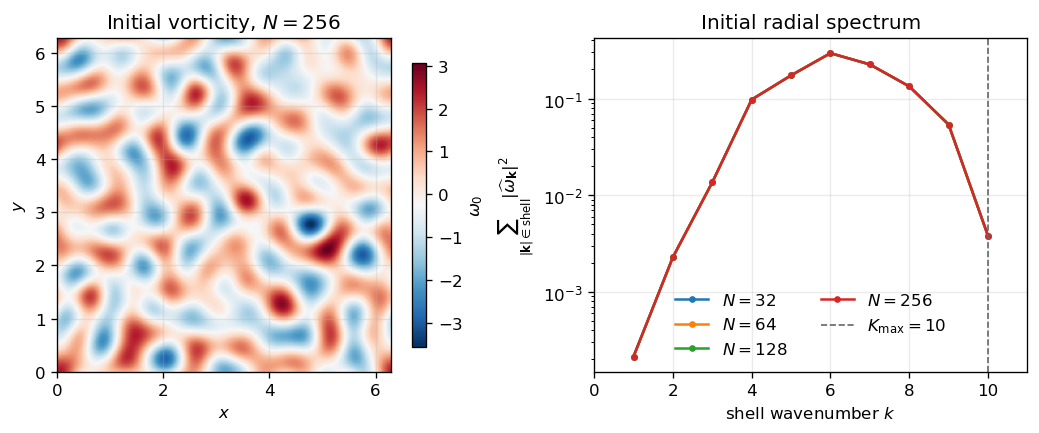

/Users/wanghaifeng/Desktop/IMEX-mr-SAV-RK/figures/isotropic_spatial_sdirk2_mrsav/initial_condition_and_spectrum.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.5), constrained_layout=True)

N_plot = max(GRID_SIZES)
image = axes[0].imshow(
    INITIAL_FIELDS[N_plot],
    origin="lower",
    extent=(DOMAIN[0], DOMAIN[2], DOMAIN[1], DOMAIN[3]),
    cmap="RdBu_r",
)
axes[0].set_title(rf"Initial vorticity, $N={N_plot}$")
axes[0].set_xlabel(r"$x$")
axes[0].set_ylabel(r"$y$")
fig.colorbar(image, ax=axes[0], shrink=0.85, label=r"$\omega_0$")

for N in GRID_SIZES:
    k, spectrum, _ = radial_spectrum(INITIAL_FIELDS[N])
    positive = (k > 0) & (k <= K_MAX) & (spectrum > 0)
    axes[1].semilogy(k[positive], spectrum[positive], "o-", ms=3, label=rf"$N={N}$")
axes[1].axvline(K_MAX, color="0.4", ls="--", lw=1, label=rf"$K_{{\max}}={K_MAX}$")
axes[1].set_xlabel(r"shell wavenumber $k$")
axes[1].set_ylabel(r"$\sum_{|\mathbf{k}|\in\mathrm{shell}}|\widehat{\omega}_{\mathbf{k}}|^2$")
axes[1].set_title("Initial radial spectrum")
axes[1].set_xlim(0, K_MAX + 1)
axes[1].legend(ncol=2)

figure_path = FIGURE_ROOT / "initial_condition_and_spectrum.png"
fig.savefig(figure_path, bbox_inches="tight")
plt.show()
print(figure_path)


## 2. 计算与 HDF5 持久化

每个算例先写入 status=incomplete，成功结束并通过有限性检查后才改为 status=complete。已有且元数据完全匹配的完整文件会被复用；不完整文件或参数冲突不会被静默覆盖。


In [21]:
def zero_force(X, Y, t):
    return np.zeros_like(X, dtype=float)


def float_tag(value):
    return f"{value:.8g}".replace("-", "m").replace(".", "p").replace("+", "")


def case_path(root, N, tau, T):
    return root / f"N{N:04d}_tau{float_tag(tau)}_T{float_tag(T)}.h5"


def expected_metadata(N, tau, T):
    return {
        "schema_version": 1,
        "method": METHOD,
        "N": int(N),
        "tau": float(tau),
        "T": float(T),
        "nu": float(NU),
        "gamma": float(GAMMA),
        "domain": np.asarray(DOMAIN, dtype=float),
        "seed": int(SEED),
        "k_max": int(K_MAX),
        "k_peak": float(K_PEAK),
        "spectral_width": float(SPECTRAL_WIDTH),
        "target_rms": float(TARGET_RMS),
        "coefficient_checksum": COEFF_CHECKSUM,
    }


def metadata_matches(handle, metadata):
    for key, expected in metadata.items():
        if key not in handle.attrs:
            return False
        actual = handle.attrs[key]
        if isinstance(expected, np.ndarray):
            if not np.allclose(np.asarray(actual), expected, rtol=0.0, atol=0.0):
                return False
        elif isinstance(expected, float):
            if not np.isclose(float(actual), expected, rtol=0.0, atol=1.0e-15):
                return False
        else:
            if actual != expected:
                return False
    return True


def load_case(path):
    path = Path(path)
    with h5py.File(path, "r") as handle:
        data = {key: handle[key][...] for key in handle.keys()}
        data["attrs"] = {key: handle.attrs[key] for key in handle.attrs}
    data["path"] = path
    return data


def run_case(N, tau, T, snapshots, root, overwrite=False):
    path = case_path(root, N, tau, T)
    metadata = expected_metadata(N, tau, T)

    if path.exists() and not overwrite:
        with h5py.File(path, "r") as handle:
            if handle.attrs.get("status", "") == "complete" and metadata_matches(handle, metadata):
                print(f"reuse complete case: {path}")
                return load_case(path)
            status = handle.attrs.get("status", "missing")
        raise RuntimeError(
            f"Refusing to overwrite {path} with status={status!r}; "
            "inspect it or set OVERWRITE=True explicitly."
        )

    initial = periodic_pad(initial_vorticity_core(N))
    solver = mrSAV_Vorticity_Stream_Periodic_Solve(
        nu=NU,
        ga=GAMMA,
        s_domain=DOMAIN,
        discrete_num=(N, N),
        initial_condition=initial,
        force_term=zero_force,
        step_method=METHOD,
        force_time_dependent=False,
    )

    path.parent.mkdir(parents=True, exist_ok=True)
    with h5py.File(path, "w") as handle:
        for key, value in metadata.items():
            handle.attrs[key] = value
        handle.attrs["status"] = "incomplete"

    started = perf_counter()
    try:
        with contextlib.redirect_stdout(io.StringIO()):
            solver.solve_fix_step((0.0, float(T)), float(tau), snapshot=np.asarray(snapshots))
        wall_time = perf_counter() - started

        arrays = {
            "Omega": np.asarray(solver.Omega),
            "tn_s": np.asarray(solver.tn_s),
            "tn": np.asarray(solver.tn),
            "tau_history": np.asarray(solver.tau),
            "q": np.asarray(solver.q),
            "Energy": np.asarray(solver.Energy),
            "Energy_rate": np.asarray(solver.Energy_rate),
            "Enstrophy": np.asarray(solver.Enstrophy),
            "Enstrophy_rate": np.asarray(solver.Enstrophy_rate),
            "Palinstrophy": np.asarray(solver.Palinstrophy),
            "Mx": np.asarray(solver.Mx),
            "CPU_time": np.asarray(solver.cpu_time),
            "mass": np.mean(np.asarray(solver.Omega), axis=(1, 2)),
        }
        finite = all(np.all(np.isfinite(value)) for value in arrays.values())
        with h5py.File(path, "a") as handle:
            for key, value in arrays.items():
                handle.create_dataset(key, data=value, compression="gzip" if value.ndim >= 2 else None)
            handle.attrs["wall_time_seconds"] = wall_time
            handle.attrs["number_of_steps"] = len(arrays["tau_history"])
            handle.attrs["status"] = "complete" if finite else "nonfinite"
        if not finite:
            raise FloatingPointError(f"Nonfinite values detected in {path}")
    except Exception as exc:
        with h5py.File(path, "a") as handle:
            handle.attrs["status"] = "failed"
            handle.attrs["error"] = repr(exc)
        raise

    result = load_case(path)
    print(
        f"completed N={N:4d}, T={T:g}, steps={result['attrs']['number_of_steps']}, "
        f"wall={result['attrs']['wall_time_seconds']:.2f} s"
    )
    return result


In [22]:
case_matrix = pd.DataFrame({
    "N": GRID_SIZES,
    "tau": TAU,
    "T": T_FINAL,
    "steps": [int(round(T_FINAL / TAU))] * len(GRID_SIZES),
    "initial_modes": len(MASTER_COEFFS),
    "dealias_cutoff": [N // 3 for N in GRID_SIZES],
})
case_matrix


,N,tau,T,steps,initial_modes,dealias_cutoff
0,32,0.001,100.0,100000,316,10
1,64,0.001,100.0,100000,316,21
2,128,0.001,100.0,100000,316,42
3,256,0.001,100.0,100000,316,85


In [23]:
smoke_results = {}
if RUN_SMOKE:
    for N in SMOKE_GRIDS:
        smoke_results[N] = run_case(
            N=N,
            tau=TAU,
            T=SMOKE_T,
            snapshots=SMOKE_SNAPSHOTS,
            root=SMOKE_ROOT,
            overwrite=OVERWRITE,
        )

    smoke_summary = pd.DataFrame([
        {
            "N": N,
            "steps": int(result["attrs"]["number_of_steps"]),
            "wall_seconds": float(result["attrs"]["wall_time_seconds"]),
            "final_energy": result["Energy"][-1],
            "final_enstrophy": result["Enstrophy"][-1],
            "max_abs_mass": np.max(np.abs(result["mass"])),
            "linear_T100_estimate_min": (
                float(result["attrs"]["wall_time_seconds"]) * T_FINAL / SMOKE_T / 60.0
            ),
            "status": result["attrs"]["status"],
        }
        for N, result in smoke_results.items()
    ])
    display(smoke_summary)
    print(
        "rough sequential T=100 estimate: "
        f"{smoke_summary['linear_T100_estimate_min'].sum():.1f} min "
        "(linear extrapolation from T=0.1)"
    )
else:
    print("Smoke test disabled.")


Smoke test disabled.


In [24]:
production_results = {}
if RUN_PRODUCTION:
    for N in GRID_SIZES:
        production_results[N] = run_case(
            N=N,
            tau=TAU,
            T=T_FINAL,
            snapshots=PRODUCTION_SNAPSHOTS,
            root=PRODUCTION_ROOT,
            overwrite=OVERWRITE,
        )
else:
    print("Production run not started. Set RUN_PRODUCTION=True after reviewing the smoke test.")


completed N=  32, T=100, steps=100000, wall=50.38 s
completed N=  64, T=100, steps=100000, wall=114.71 s
completed N= 128, T=100, steps=100000, wall=622.93 s
completed N= 256, T=100, steps=100000, wall=2583.56 s


In [25]:
# Optional temporal-error isolation at a fixed spatial grid.
# This is deliberately separate from the spatial-resolution experiment.
time_check_results = {}
if RUN_TIME_CHECK:
    for tau in (TAU, TAU / 2.0):
        snapshots = np.array([0.0, TIME_CHECK_T])
        time_check_results[tau] = run_case(
            N=TIME_CHECK_N,
            tau=tau,
            T=TIME_CHECK_T,
            snapshots=snapshots,
            root=TIME_CHECK_ROOT,
            overwrite=OVERWRITE,
        )
    temporal_error = common_mode_relative_error(
        time_check_results[TAU]["Omega"][-1],
        time_check_results[TAU / 2.0]["Omega"][-1],
    )
    print(f"fixed-N temporal difference at T={TIME_CHECK_T:g}: {temporal_error:.6e}")
else:
    print("Optional tau versus tau/2 check disabled.")


Optional tau versus tau/2 check disabled.


## 3. 可用结果的诊断

若生产数据存在，则优先分析完整 \(T=100\) 结果；否则分析本次 smoke test。相位敏感的公共 Fourier 模态误差只用于同一物理时间的短时比较。长时间后主要比较径向谱及其后半段时间平均，以避免把相位漂移直接解释为空间统计误差。


In [26]:
def discover_complete_cases(root, grids, tau, T):
    discovered = {}
    for N in grids:
        path = case_path(root, N, tau, T)
        if not path.exists():
            continue
        with h5py.File(path, "r") as handle:
            expected = expected_metadata(N, tau, T)
            if handle.attrs.get("status", "") == "complete" and metadata_matches(handle, expected):
                discovered[N] = load_case(path)
    return discovered


available_results = discover_complete_cases(PRODUCTION_ROOT, GRID_SIZES, TAU, T_FINAL)
result_kind = "production"
if len(available_results) < 2:
    available_results = discover_complete_cases(SMOKE_ROOT, SMOKE_GRIDS, TAU, SMOKE_T)
    result_kind = "smoke"

if len(available_results) < 2:
    raise RuntimeError("At least two complete cases are required for the spatial comparison.")

available_grids = tuple(sorted(available_results))
reference_N = max(available_grids)
common_T = min(float(available_results[N]["tn_s"][-1]) for N in available_grids)
print(f"Analyzing {result_kind} data on grids {available_grids}; reference N={reference_N}, T={common_T:g}.")


Analyzing production data on grids (32, 64, 128, 256); reference N=256, T=100.


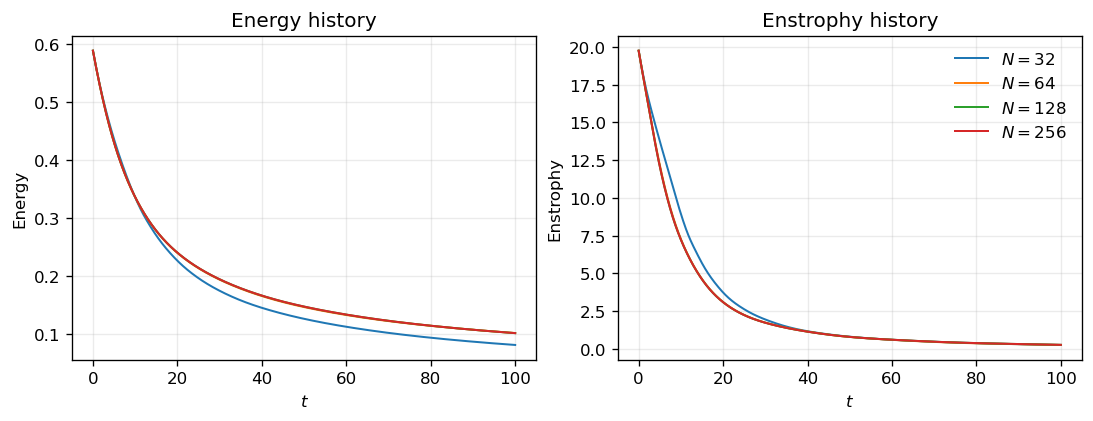

/Users/wanghaifeng/Desktop/IMEX-mr-SAV-RK/figures/isotropic_spatial_sdirk2_mrsav/production_energy_enstrophy.png


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.4), constrained_layout=True)
for N in available_grids:
    result = available_results[N]
    axes[0].plot(result["tn"], result["Energy"], lw=1.2, label=rf"$N={N}$")
    axes[1].plot(result["tn"], result["Enstrophy"], lw=1.2, label=rf"$N={N}$")

axes[0].set_xlabel(r"$t$")
axes[0].set_ylabel("Energy")
axes[0].set_title("Energy history")
axes[1].set_xlabel(r"$t$")
axes[1].set_ylabel("Enstrophy")
axes[1].set_title("Enstrophy history")
axes[1].legend()

figure_path = FIGURE_ROOT / f"{result_kind}_energy_enstrophy.png"
fig.savefig(figure_path, bbox_inches="tight")
plt.show()
print(figure_path)


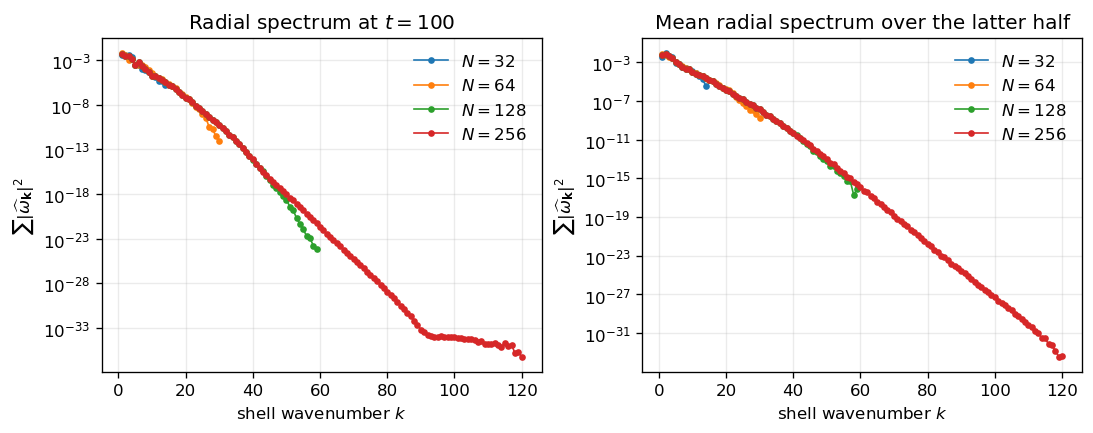

/Users/wanghaifeng/Desktop/IMEX-mr-SAV-RK/figures/isotropic_spatial_sdirk2_mrsav/production_radial_spectra.png


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.5), constrained_layout=True)

mean_spectra = {}
for N in available_grids:
    result = available_results[N]
    final_field = result["Omega"][-1]
    k, spectrum, _ = radial_spectrum(final_field)
    positive = (k > 0) & (spectrum > 0)
    axes[0].semilogy(k[positive], spectrum[positive], "o-", ms=3, lw=1, label=rf"$N={N}$")

    averaging_start = 0.5 * float(result["tn_s"][-1])
    k_mean, spectrum_mean = mean_radial_spectrum(result["Omega"], result["tn_s"], averaging_start)
    mean_spectra[N] = (k_mean, spectrum_mean)
    positive_mean = (k_mean > 0) & (spectrum_mean > 0)
    axes[1].semilogy(
        k_mean[positive_mean],
        spectrum_mean[positive_mean],
        "o-",
        ms=3,
        lw=1,
        label=rf"$N={N}$",
    )

axes[0].set_title(rf"Radial spectrum at $t={common_T:g}$")
axes[1].set_title(r"Mean radial spectrum over the latter half")
for axis in axes:
    axis.set_xlabel(r"shell wavenumber $k$")
    axis.set_ylabel(r"$\sum |\widehat{\omega}_{\mathbf{k}}|^2$")
    axis.legend()

figure_path = FIGURE_ROOT / f"{result_kind}_radial_spectra.png"
fig.savefig(figure_path, bbox_inches="tight")
plt.show()
print(figure_path)


In [29]:
reference = available_results[reference_N]
reference_final = reference["Omega"][-1]
reference_k_mean, reference_spectrum_mean = mean_spectra[reference_N]

rows = []
for N in available_grids:
    result = available_results[N]
    final_field = result["Omega"][-1]
    k_mean, spectrum_mean = mean_spectra[N]
    cutoff = min(N // 3, reference_N // 3)
    upper = min(cutoff, len(spectrum_mean) - 1, len(reference_spectrum_mean) - 1)
    mean_spectrum_l1 = (
        np.sum(np.abs(spectrum_mean[1:upper + 1] - reference_spectrum_mean[1:upper + 1]))
        / max(np.sum(np.abs(reference_spectrum_mean[1:upper + 1])), np.finfo(float).tiny)
    )
    rows.append({
        "N": N,
        "common_cutoff": cutoff,
        "final_common_mode_rel_L2": common_mode_relative_error(final_field, reference_final, cutoff),
        "final_radial_spectrum_rel_L1": radial_relative_l1(final_field, reference_final, cutoff),
        "mean_radial_spectrum_rel_L1": mean_spectrum_l1,
        "final_tail_fraction_k_ge_8": tail_fraction(final_field, k_tail=8),
        "max_abs_mass": np.max(np.abs(result["mass"])),
        "wall_seconds": float(result["attrs"]["wall_time_seconds"]),
    })

spectral_comparison = pd.DataFrame(rows)
display(spectral_comparison.style.format({
    "final_common_mode_rel_L2": "{:.3e}",
    "final_radial_spectrum_rel_L1": "{:.3e}",
    "mean_radial_spectrum_rel_L1": "{:.3e}",
    "final_tail_fraction_k_ge_8": "{:.3e}",
    "max_abs_mass": "{:.3e}",
    "wall_seconds": "{:.2f}",
}))


,N,common_cutoff,final_common_mode_rel_L2,final_radial_spectrum_rel_L1,mean_radial_spectrum_rel_L1,final_tail_fraction_k_ge_8,max_abs_mass,wall_seconds
0,32,10,1.310e+00,2.915e-01,2.325e-01,1.376e-02,6.939e-18,50.38
1,64,21,7.187e-01,3.174e-01,1.152e-01,2.490e-02,1.041e-17,114.71
2,128,42,8.221e-03,2.022e-03,1.068e-03,1.560e-02,5.204e-18,622.93
3,256,85,0.000e+00,0.000e+00,0.000e+00,1.557e-02,5.204e-18,2583.56


In [30]:
# The common-mode error must be at roundoff level at t=0; otherwise the
# comparison is contaminated by inconsistent initial data.
initial_reference = INITIAL_FIELDS[reference_N]
initial_errors = {
    N: common_mode_relative_error(INITIAL_FIELDS[N], initial_reference)
    for N in available_grids
}
assert max(initial_errors.values()) < 1.0e-12
print("Initial common-mode relative errors:", initial_errors)


Initial common-mode relative errors: {32: np.float64(2.1165549036642589e-16), 64: np.float64(2.411427415220423e-16), 128: np.float64(2.888217753923669e-16), 256: np.float64(0.0)}


## 4. 结果解释准则

1. 初始公共模态误差必须处于舍入误差量级，否则不能把后续差异归因于空间离散。
2. 在短时间内，final_common_mode_rel_L2 可直接衡量相位与幅值的空间误差。
3. 对 \(T=100\) 的长时间结果，不应把瞬时场的相位差直接当成统计不一致；应重点比较径向谱、后半段平均径向谱和固定物理阈值 \(k\geq8\) 的高频尾部占比。
4. 若 \(\tau=10^{-3}\) 的时间误差不可忽略，应启用独立的 RUN_TIME_CHECK，并在固定空间网格上与 \(\tau/2\) 比较后再解释空间收敛性。
